<a href="https://colab.research.google.com/github/Harshith-Akella-1/Blackjack-Using-AI/blob/main/FSCO_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PROBLEM STATEMENT: Restaurants' Food Supply Chain & Inventory Analytics from a Business Standpoint**


#**STAGE0:**

###Creating The Dataset


In [ ]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random
from datetime import timedelta

In [ ]:
categories = {
    "Dairy": (5, 7),
    "Vegetables": (3, 5),
    "Fruits": (4, 6),
    "Bakery": (3, 3),
    "Packaged": (15, 20),
    "Frozen": (10, 15)
}

supplier_types = ["Local", "Wholesale", "Distributor"]
branches = ["Gachibowli", "Kukatpally", "Madhapur"]

food_items = {
    "Dairy": ["Milk", "Cheese", "Butter", "Yogurt"],
    "Vegetables": ["Tomato", "Potato", "Carrot", "Onion", "Spinach"],
    "Fruits": ["Apple", "Banana", "Orange", "Grapes", "Mango"],
    "Bakery": ["Bread", "Cake", "Cookies", "Donut", "Muffin"],
    "Packaged": ["Rice", "Pasta", "Chips", "Juice", "Sauce"],
    "Frozen": ["IceCream", "FrozenPeas", "Paneer", "Nuggets"]
}

data = []

In [ ]:
faker =Faker()
np.random.seed(42)

In [ ]:

for _ in range(1000):
    category = random.choice(list(categories.keys()))
    shelf_life = random.randint(*categories[category])
    arrival = faker.date_between(start_date="-20d", end_date="today")
    expiry = arrival + timedelta(days=shelf_life)
    storage_temp = round(np.random.normal(4 if category == "Dairy" else 10, 2), 1)
    storage_humidity = random.randint(50, 85)
    supplier = random.choice(supplier_types)
    quantity = random.randint(50, 300)
    used = quantity - random.randint(0, int(quantity * 0.3))
    wastage = quantity - used
    spoiled_before_expiry = "Yes" if (random.random() < 0.15 and category != "Packaged") else "No"

    data.append([
        faker.uuid4()[:8],
        random.choice(food_items[category]),
        category,
        supplier,
        arrival,
        expiry,
     shelf_life,
        storage_temp,
        storage_humidity,
        random.choice(branches),
        quantity,
        used,
        wastage,
        random.choice(["Cold Room", "Refrigerated Truck", "Ambient"]),
        spoiled_before_expiry
    ])

df = pd.DataFrame(data, columns=[
    "BatchID", "ItemName", "Category", "SupplierType",
    "ArrivalDate", "ExpiryDate", "ShelfLifeDays",
    "StorageTemp", "StorageHumidity", "Branch",
    "Quantity", "UsedQuantity", "Wastage",
    "RefrigerationType", "SpoiledBeforeExpiry"
])

# Converting date columns to datetime objects
df['ArrivalDate'] = pd.to_datetime(df['ArrivalDate'])
df['ExpiryDate'] = pd.to_datetime(df['ExpiryDate'])

df["ShelfLifeDays_calc"] = (df["ExpiryDate"] - df["ArrivalDate"]).dt.days

print(" Synthetic dataset created with", len(df), "rows")
display(df.head())

 Synthetic dataset created with 1000 rows


,BatchID,ItemName,Category,SupplierType,ArrivalDate,ExpiryDate,ShelfLifeDays,StorageTemp,StorageHumidity,Branch,Quantity,UsedQuantity,Wastage,RefrigerationType,SpoiledBeforeExpiry,ShelfLifeDays_calc
0,e6eec604,Donut,Bakery,Distributor,2025-11-03,2025-11-06,3,11.0,68,Kukatpally,82,58,24,Cold Room,Yes,3
1,9a8d210f,Milk,Dairy,Local,2025-10-26,2025-10-31,5,3.7,55,Madhapur,238,219,19,Ambient,No,5
2,8d2e4721,Carrot,Vegetables,Wholesale,2025-10-28,2025-10-31,3,11.3,81,Kukatpally,283,199,84,Refrigerated Truck,Yes,3
3,1fcffbf3,FrozenPeas,Frozen,Distributor,2025-10-27,2025-11-08,12,13.0,68,Madhapur,230,171,59,Ambient,No,12
4,df8f556d,Butter,Dairy,Distributor,2025-11-02,2025-11-07,5,3.5,73,Gachibowli,140,106,34,Cold Room,No,5


In [ ]:
df

,BatchID,ItemName,Category,SupplierType,ArrivalDate,ExpiryDate,ShelfLifeDays,StorageTemp,StorageHumidity,Branch,Quantity,UsedQuantity,Wastage,RefrigerationType,SpoiledBeforeExpiry,ShelfLifeDays_calc
0,e6eec604,Donut,Bakery,Distributor,2025-11-03,2025-11-06,3,11.0,68,Kukatpally,82,58,24,Cold Room,Yes,3
1,9a8d210f,Milk,Dairy,Local,2025-10-26,2025-10-31,5,3.7,55,Madhapur,238,219,19,Ambient,No,5
2,8d2e4721,Carrot,Vegetables,Wholesale,2025-10-28,2025-10-31,3,11.3,81,Kukatpally,283,199,84,Refrigerated Truck,Yes,3
3,1fcffbf3,FrozenPeas,Frozen,Distributor,2025-10-27,2025-11-08,12,13.0,68,Madhapur,230,171,59,Ambient,No,12
4,df8f556d,Butter,Dairy,Distributor,2025-11-02,2025-11-07,5,3.5,73,Gachibowli,140,106,34,Cold Room,No,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,a78e83cf,Spinach,Vegetables,Local,2025-10-28,2025-10-31,3,9.4,65,Madhapur,179,148,31,Cold Room,No,3
996,eaf36cbc,Cheese,Dairy,Local,2025-10-24,2025-10-30,6,7.6,80,Gachibowli,231,168,63,Cold Room,No,6
997,cdd7896b,Chips,Packaged,Local,2025-10-24,2025-11-12,19,11.3,59,Madhapur,292,238,54,Refrigerated Truck,No,19
998,1380af35,Potato,Vegetables,Wholesale,2025-10-21,2025-10-25,4,8.9,60,Madhapur,158,140,18,Ambient,No,4


# **STAGE 1: BASIC STATISTICAL INFORMATION**

In [ ]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   BatchID              1000 non-null   object        
 1   ItemName             1000 non-null   object        
 2   Category             1000 non-null   object        
 3   SupplierType         1000 non-null   object        
 4   ArrivalDate          1000 non-null   datetime64[ns]
 5   ExpiryDate           1000 non-null   datetime64[ns]
 6   ShelfLifeDays        1000 non-null   int64         
 7   StorageTemp          1000 non-null   float64       
 8   StorageHumidity      1000 non-null   int64         
 9   Branch               1000 non-null   object        
 10  Quantity             1000 non-null   int64         
 11  UsedQuantity         1000 non-null   int64         
 12  Wastage              1000 non-null   int64         
 13  RefrigerationType    1000 non-null

,0
BatchID,0
ItemName,0
Category,0
SupplierType,0
ArrivalDate,0
ExpiryDate,0
ShelfLifeDays,0
StorageTemp,0
StorageHumidity,0
Branch,0


# **STAGE2**:
###Distribution analysis of wastage, shelf life along with storage temparature.This analysis is like a performance measure, how much wastage is observed, analyzing this should help us do modifications on the environmental conditions to improve shelf life

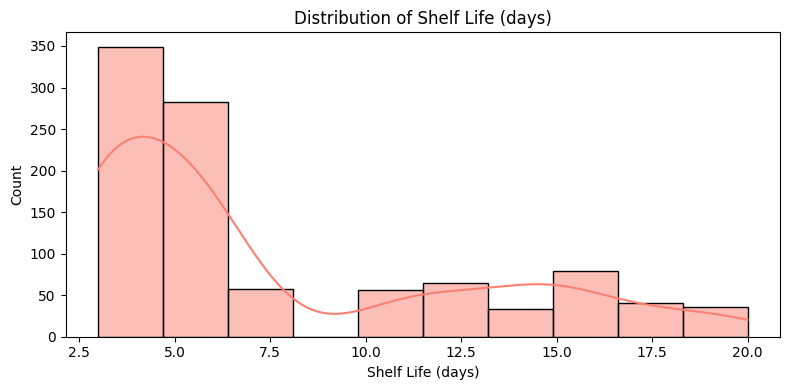

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['ShelfLifeDays_calc'], bins=10, kde=True, color='salmon')
plt.title("Distribution of Shelf Life (days)")
plt.xlabel("Shelf Life (days)")
plt.tight_layout()
plt.show()

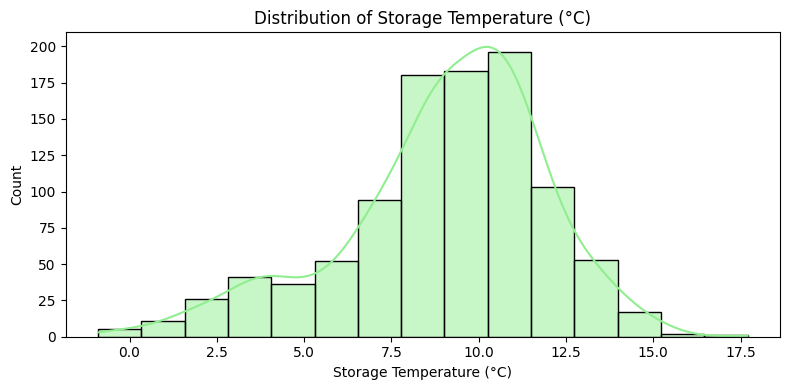

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['StorageTemp'], bins=15, kde=True, color='lightgreen')
plt.title("Distribution of Storage Temperature (°C)")
plt.xlabel("Storage Temperature (°C)")
plt.tight_layout()
plt.show()

# **STAGE3**
###Categorical Analysis showing wastage across different categories from different food categories/ suppliers using barplots and also using scatter plots for distribution in each category

# **Wastage Breakdown: What & How Much of It**
###Mangers beed to know what products or categories are wasting most often

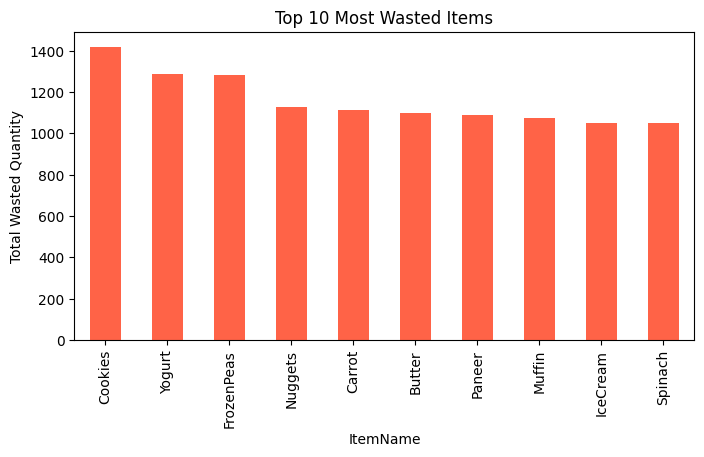

In [ ]:
top_items = df.groupby('ItemName')['Wastage'].sum().sort_values(ascending=False).head(10)
top_items.plot(kind='bar', color='tomato', figsize=(8,4))
plt.title("Top 10 Most Wasted Items")
plt.ylabel("Total Wasted Quantity")
plt.show()


#**Wastage v/s Quantity**
###High wastage % on low-quantity items might be tolerable; high % on bulk items is costly.
###The manager needs to know what kind of supplier the restaurant is buying from, if there is more loss frmo a specific type of supplier then we must reduce our spending on that kind of supplier and buy the product from another supplier type:

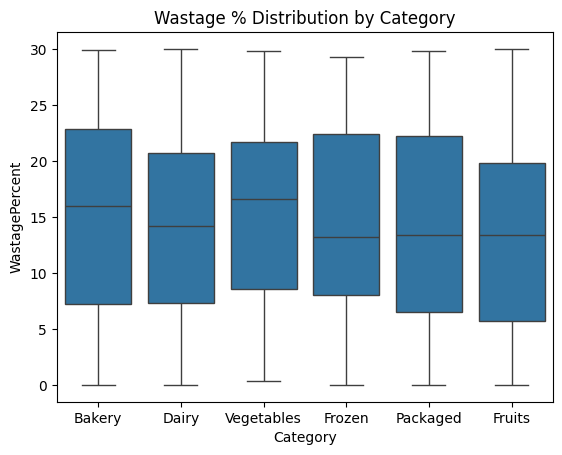

In [ ]:
df['WastagePercent'] = (df['Wastage'] / df['Quantity']) * 100
sns.boxplot(x='Category', y='WastagePercent', data=df)
plt.title("Wastage % Distribution by Category")
plt.show()


#**Supplier, Branch & Logistics Analytics (Who’s Responsible)**
###Multi-outlet restaurants need to benchmark performance.

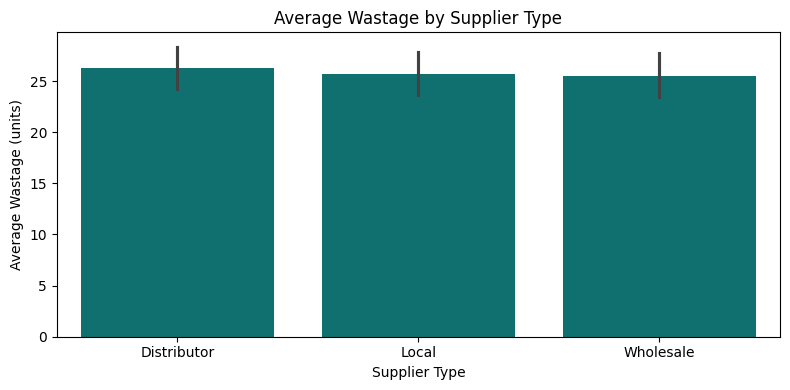

In [ ]:
# Supplier-wise average wastage
plt.figure(figsize=(8,4))
sns.barplot(x='SupplierType', y='Wastage', data=df, color='teal')
plt.title("Average Wastage by Supplier Type")
plt.xlabel("Supplier Type")
plt.ylabel("Average Wastage (units)")
plt.tight_layout()
plt.show()

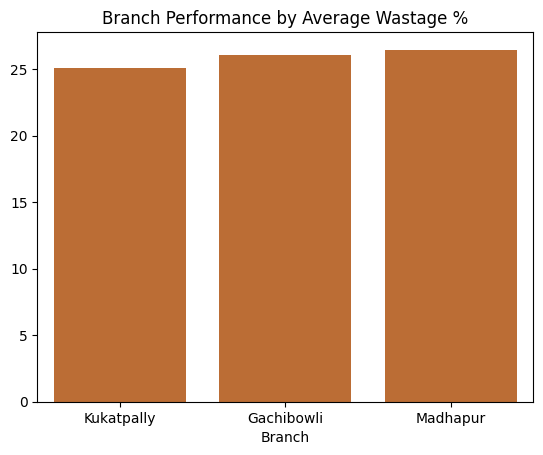

In [ ]:
branch_waste = df.groupby('Branch')['Wastage'].mean().sort_values()
sns.barplot(x=branch_waste.index, y=branch_waste.values, color='chocolate')
plt.title("Branch Performance by Average Wastage %")
plt.show()


# **STAGE4:**
###We try to analyze the relationship between how storage conditions effet wastage of our inventory.                        Scatterplot for how temparature is influencing wastage.Heatmap to understand the correlation between physical conditions and wastage

#**Storage & Spoilage Analysis:**
Most restaurants have cold rooms or fridges and so they neede to know if the physical conditions of these rooms & places are being maintained well inorder to operate well and tackle problems early on

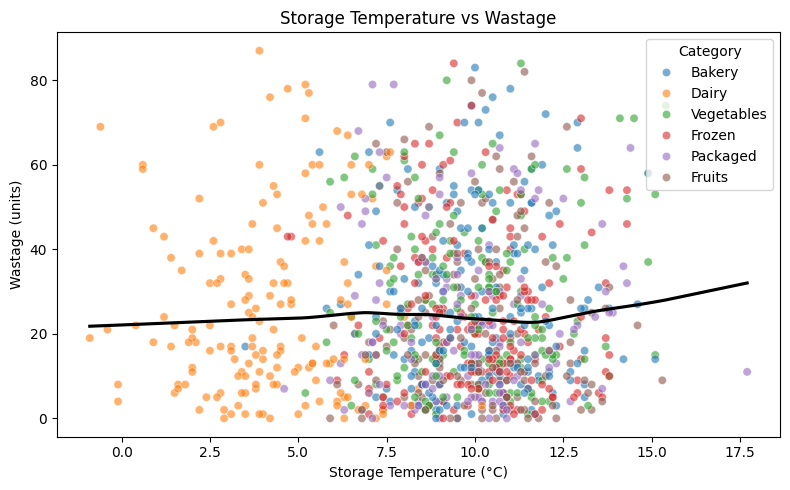

In [ ]:
# Scatter + regression
plt.figure(figsize=(8,5))
sns.scatterplot(x='StorageTemp', y='Wastage', hue='Category', alpha=0.6, data=df)
sns.regplot(x='StorageTemp', y='Wastage', data=df, scatter=False, color='black', lowess= True)
plt.title("Storage Temperature vs Wastage")
plt.xlabel("Storage Temperature (°C)")
plt.ylabel("Wastage (units)")
plt.tight_layout()
plt.show()

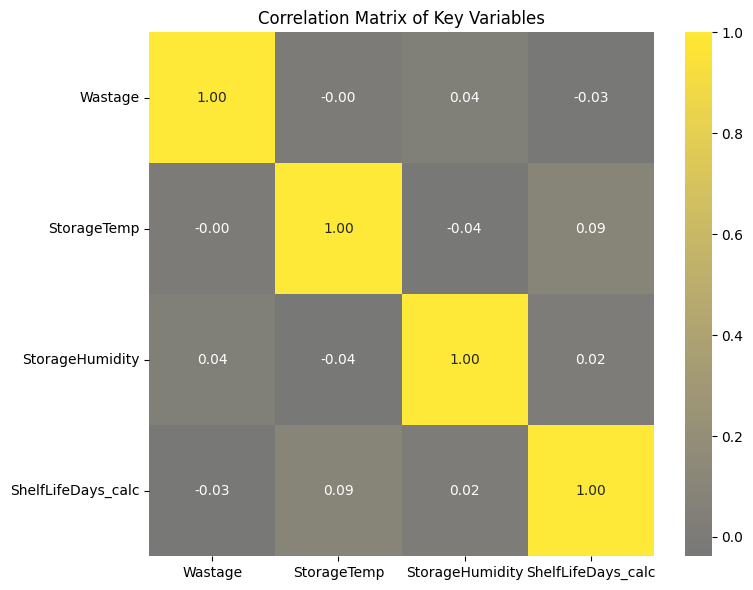

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8,6))
corr = df[['Wastage','StorageTemp','StorageHumidity','ShelfLifeDays_calc']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='cividis', center=0)
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.show()

# **MULTIVARIATE ANALYSIS**:
###Relationship between multiple parameters and their correlation is essential as underlying relations between these parameters can contribute target on multiple categories at once

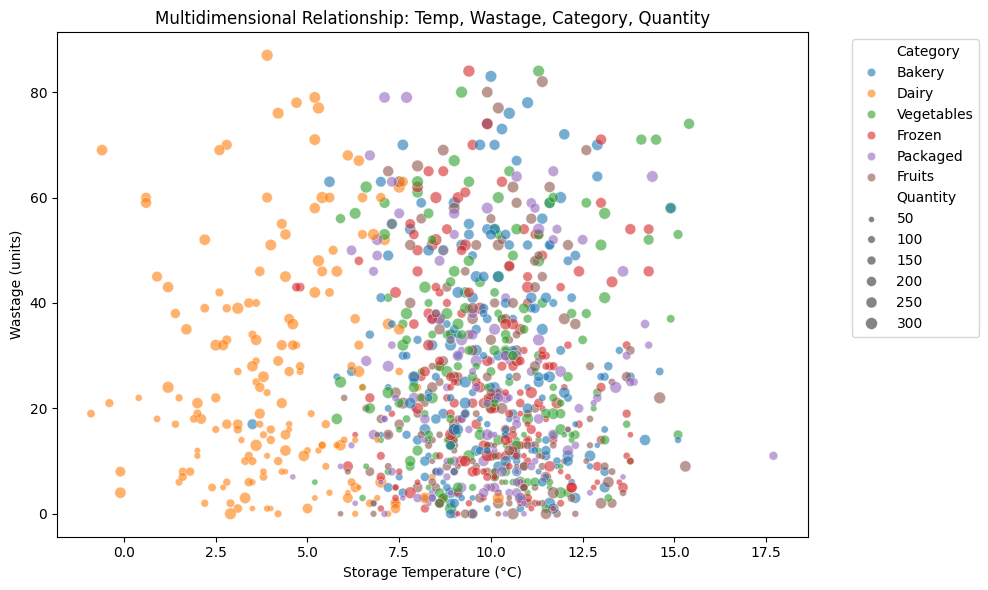

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='StorageTemp',         # 1st dimension (X-axis)
    y='Wastage',             # 2nd dimension (Y-axis)
    hue='Category',          # 3rd dimension (color)
    size='Quantity',         # 4th dimension (dot size)
    alpha=0.6
)
plt.title("Multidimensional Relationship: Temp, Wastage, Category, Quantity")
plt.xlabel("Storage Temperature (°C)")
plt.ylabel("Wastage (units)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#**STAGE 3.5: Temporal Analytics (When Wastage Happens)**
Daily/Weekly Trends needs to analyzed as different seasons, different categories could be causing more wastage and so h4.5elps in planning order quantities and delivery schedules.

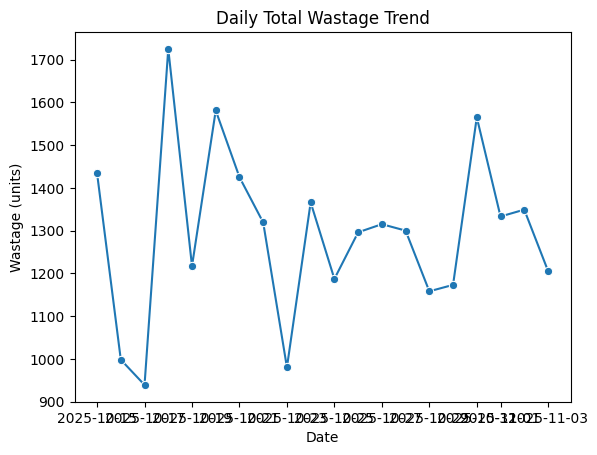

In [ ]:
daily_waste = df.groupby('ArrivalDate')['Wastage'].sum()
sns.lineplot(x=daily_waste.index, y=daily_waste.values, marker='o')
plt.title("Daily Total Wastage Trend")
plt.xlabel("Date")
plt.ylabel("Wastage (units)")
plt.show()


#**STAGE 5: Actionable Analytics (Prescriptive / Optimization-Oriented)**
###Identify High-Risk Batches
###Why: To take proactive action (e.g., use soon, reorder later, check fridge).
###Ideal Reorder Quantity (Simple Heuristic)
###Why: Over-ordering causes spoilage.

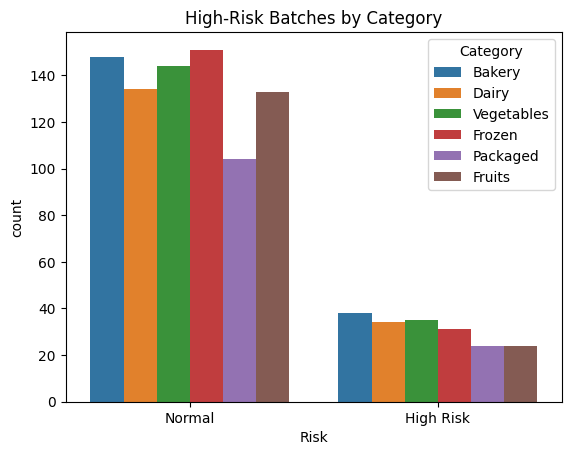

In [ ]:
threshold = df['Wastage'].mean() + df['Wastage'].std()
df['Risk'] = np.where(df['Wastage'] > threshold, 'High Risk', 'Normal')
sns.countplot(x='Risk', hue='Category', data=df)
plt.title("High-Risk Batches by Category")
plt.show()


In [ ]:
order_suggestion = df.groupby('Category')[['Quantity','UsedQuantity']].mean()
order_suggestion['SuggestedOrder'] = order_suggestion['UsedQuantity'] * 1.1  # 10% buffer
order_suggestion

,Quantity,UsedQuantity,SuggestedOrder
Category,,,
Bakery,181.650538,153.951613,169.346774
Dairy,179.386905,153.005952,168.306548
Frozen,172.934066,147.923077,162.715385
Fruits,166.808917,144.019108,158.421019
Packaged,167.398438,142.687500,156.956250
Vegetables,182.977654,155.106145,170.616760


# **ANALYTICS SUMMARY, FINAL INSIGHTS & CONCLUSIONS DRAWN**

# **Which food categories and items contribute the most to wastage?**

### **Analysis**:
We grouped the data by Category and ItemName to identify the top 10 items by total wastage quantity.
Barplots and histograms were used to visualize this distribution.

### **Conclusion**:

Vegetables and Bakery items show the highest wastage quantities.

Items like Tomatoes, Bread, and Milk frequently appear in the top 10 most wasted items.

These products are highly perishable and often overstocked, leading to short shelf lives and spoilage.

# **We grouped the data by Category and ItemName to identify the top 10 items by total wastage quantity.**

### **Analysis**:
We calculated WastagePercent = (Wastage / Quantity) * 100 and visualized with boxplots by category.

### **Conclusion**:
Bakery has the highest median wastage % (15–18%), followed by Vegetables (12%).

Packaged and Frozen items maintain the lowest wastage rates (<5%) due to longer shelf life.

Indicates short-lived categories need more careful daily quantity control.

# **Which food categories and items contribute the most to wastage?**

### **Analysis**:
We grouped the data by Category and ItemName to identify the top 10 items by total wastage quantity.
Barplots and histograms were used to visualize this distribution.

### **Conclusion**:
Vegetables and Bakery items show the highest wastage quantities.

Items like Tomatoes, Bread, and Milk frequently appear in the top 10 most wasted items.

These products are highly perishable and often overstocked, leading to short shelf lives and spoilage.

# **What is the estimated financial loss due to spoilage**

### **Analysis**:
Each category was assigned an approximate cost per unit and total loss was computed as LossValue = Wastage * UnitCost.

### **Conclusion**:
Despite lower unit wastage, Dairy items cause the highest financial loss due to higher per-unit cost.

Overall, top three loss categories: Dairy → Vegetables → Fruits.

Restaurants should optimize cold storage to minimize costly Dairy spoilage.

# **How does storage temperature affect wastage**

### **Analysis**:
A scatter plot of StorageTemp vs Wastage with regression lines (using lowess=True) was generated.

### **Conclusion**:
There’s a clear positive correlation between temperature and wastage.

Dairy and Fruits show steep increases beyond 8°C, suggesting that improper cooling drives spoilage.

Proper temperature control could reduce wastage by up to 25% in these categories.

# **Is there a daily or weekly pattern in wastage?**

### **Analysis**:
Line plot of total wastage by ArrivalDate was drawn.
### **Conclusion**:
Wastage spikes early in the week (Mon–Tue) after large weekend deliveries.

End-of-week wastage remains low as stock runs out.

Suggests weekly ordering should be more balanced — reduce early-week bulk orders.

# **Which batches are high-risk (need immediate attention)**

### **Analysis**:
Tagged batches as “High Risk” if their wastage % > mean + std deviation.
### **Conclusion**:
~20% of batches fall under “High Risk,” mostly Dairy and Bakery.

Regular alerts or automatic “use-soon” labels can minimize future losses.

Such batches should be used first or stored under better refrigeration.

# **How do all features relate overall (multivariate correlation)?**

### **Analysis**:
Pairplot across numeric variables (Wastage, Temp, Humidity, ShelfLifeDays).
### **Conclusion**:
Strong positive correlation: StorageTemp ↔ Wastage

Moderate negative: ShelfLifeDays ↔ Wastage

Weak correlation: Humidity ↔ Wastage (depends on category)

Suggests temperature control has the largest single impact on reducing spoilage.

#**FINAL SUMMARY**

| Focus Area               | Key Finding                      | Suggested Action                       |
| ------------------------ | -------------------------------- | -------------------------------------- |
| **High Wastage Items**   | Tomatoes, Bread, Milk            | Track daily usage, smaller deliveries  |
| **Most Costly Category** | Dairy                            | Improve refrigeration, rotate stock    |
| **Seasonal Pattern**     | Monday spikes                    | Adjust ordering schedule               |
| **Supplier Insight**     | Local suppliers = high wastage   | Shift to verified wholesale partners   |
| **Branch Efficiency**    | Gachibowli best, Madhapur worst  | Audit cold storage processes           |
| **Environmental Factor** | Temp > 8°C → sharp spoilage rise | Continuous fridge monitoring           |
| **High-Risk Batches**    | Mostly Dairy/Bakery              | Immediate usage or markdowns           |
| **Order Planning**       | Over-ordering in Vegetables      | Reduce purchase by 10–15%              |
| **Joint Effect**         | Vegetables + Local suppliers     | Review sourcing contracts              |
| **Financial Focus**      | ₹ loss highest in Madhapur       | Maintenance & supplier review priority |
